In [1]:
import dpkt
import os
import pandas as pd
from utils.util import create_directory_if_not_exists, find_files_with_extension
from utils.plotter import plot_siftr_graph


# Convert bytes to Mbit/s
def bytes_to_mbits(bytes):
    return (bytes * 8) / 1_000_000

# Read pcap file and get throughput per second for specific ports
def read_pcap(file_path):
    ports = [5101, 5102, 5103, 8082]
    throughput_per_second = {port: {} for port in ports}
    goodput_per_second = {port: {} for port in ports}
    total_throughput = {port: 0 for port in ports}
    total_goodput = {port: 0 for port in ports}

    start_time = None

    with open(file_path, 'rb') as f:
        pcap = dpkt.pcap.Reader(f)

        for timestamp, buf in pcap:
            eth = dpkt.ethernet.Ethernet(buf)
            if not isinstance(eth.data, dpkt.ip.IP):
                continue

            ip = eth.data
            l4 = ip.data  # TCP or UDP

            if isinstance(l4, (dpkt.tcp.TCP, dpkt.udp.UDP)):
                dest_port = l4.dport
                if dest_port not in throughput_per_second:
                    continue

                pkt_length = len(buf)
                l4_hdr_len = 0

                # Estimate L4 header length
                if isinstance(l4, dpkt.tcp.TCP):
                    l4_hdr_len = (l4.off * 4)  # TCP offset is in 32-bit words
                elif isinstance(l4, dpkt.udp.UDP):
                    l4_hdr_len = 8  # UDP header is fixed at 8 bytes

                app_payload_len = len(l4.data)

                if start_time is None:
                    start_time = timestamp

                normalized_time = int(timestamp - start_time)

                # Throughput (includes headers)
                if normalized_time not in throughput_per_second[dest_port]:
                    throughput_per_second[dest_port][normalized_time] = pkt_length
                else:
                    throughput_per_second[dest_port][normalized_time] += pkt_length

                # Goodput (payload only)
                if normalized_time not in goodput_per_second[dest_port]:
                    goodput_per_second[dest_port][normalized_time] = app_payload_len
                else:
                    goodput_per_second[dest_port][normalized_time] += app_payload_len

                total_throughput[dest_port] += pkt_length
                total_goodput[dest_port] += app_payload_len

    return throughput_per_second, goodput_per_second, total_throughput, total_goodput


# Plot throughput using plot_siftr_graph
def plot_throughput_with_siftr(file_path, ycolumn, title, xlabel, ylabel, filename, graph_directory, use_goodput=False):
    throughput, goodput, total_thrpt, total_goodpt = read_pcap(file_path)

    
    data_source = goodput if use_goodput else throughput
    total_source = total_goodpt if use_goodput else total_thrpt

    print(total_source.items())

    paths = {}
    print(f"Total {'goodput' if use_goodput else 'throughput'} for {filename}: {total_source}")

    for port, data in data_source.items():
        if port not in [5102, 8082]:
            continue
        sorted_data = sorted(data.items())
        times = [item[0] for item in sorted_data]
        mbits_transferred = [bytes_to_mbits(item[1]) for item in sorted_data]

        path_df = pd.DataFrame({'Time': times, ycolumn: mbits_transferred})
        path_label = f"Port {port}"
        if port == 8082:
            path_label = "UDP-Prague"
        if port == 5102:
            path_label = "Cubic"

        paths[path_label] = path_df

    create_directory_if_not_exists(graph_directory)
    plot_siftr_graph(paths, ycolumn, title, xlabel, ylabel, filename, graph_directory)


# Main execution
mainpth="../data/udp_data_2025-04-11"
mainpth="../data/udp_data_2025-04-27"
graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

folderpath = os.path.join(mainpth, "server_data")

# Use the new find_files_with_extension function
filenames, filepaths, file_dict = find_files_with_extension(paths=[folderpath], extension='.em1.pcap')

from utils.thrpt_util import analysis_pcap_tcp

Directory already exists: ../data/udp_data_2025-04-27\Graphs


In [2]:
# # Plot throughput for each pcap file
# for filename, filepath in zip(filenames, filepaths):
#     print(filename)
#     analysis_pcap_tcp(filepath)

dict_items([(5101, 0), (5102, 317206413), (5103, 0), (8082, 234313468)])
Total throughput for 1_dualpi2_100Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 317206413, 5103: 0, 8082: 234313468}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


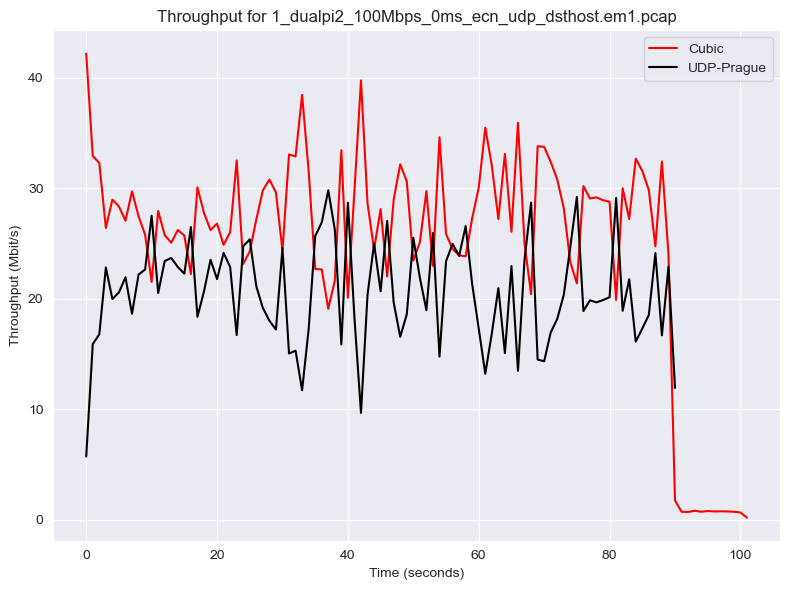

dict_items([(5101, 0), (5102, 309043579), (5103, 0), (8082, 221094594)])
Total throughput for 1_dualpi2_100Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 309043579, 5103: 0, 8082: 221094594}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


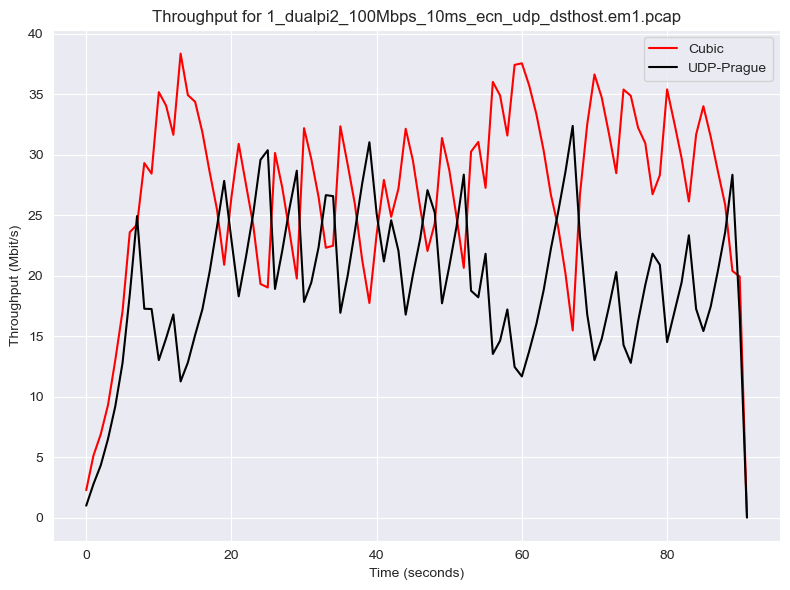

dict_items([(5101, 0), (5102, 298844125), (5103, 0), (8082, 159312104)])
Total throughput for 1_dualpi2_100Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 298844125, 5103: 0, 8082: 159312104}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


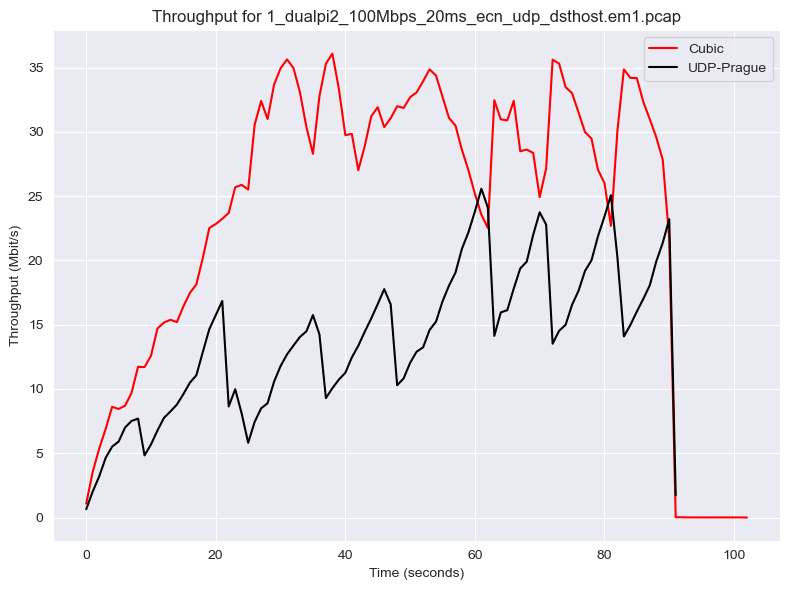

dict_items([(5101, 0), (5102, 318537156), (5103, 0), (8082, 233611214)])
Total throughput for 1_dualpi2_100Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 318537156, 5103: 0, 8082: 233611214}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


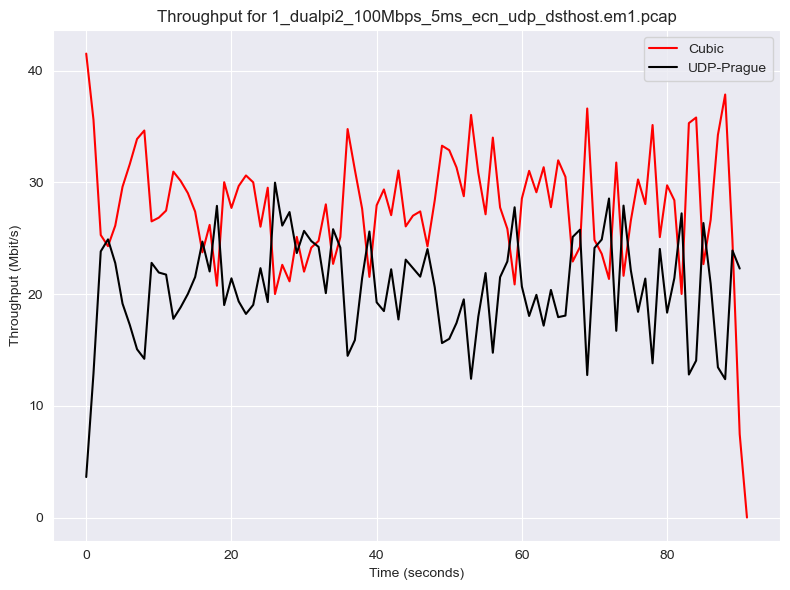

dict_items([(5101, 0), (5102, 17755365), (5103, 0), (8082, 37665766)])
Total throughput for 1_dualpi2_10Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 17755365, 5103: 0, 8082: 37665766}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


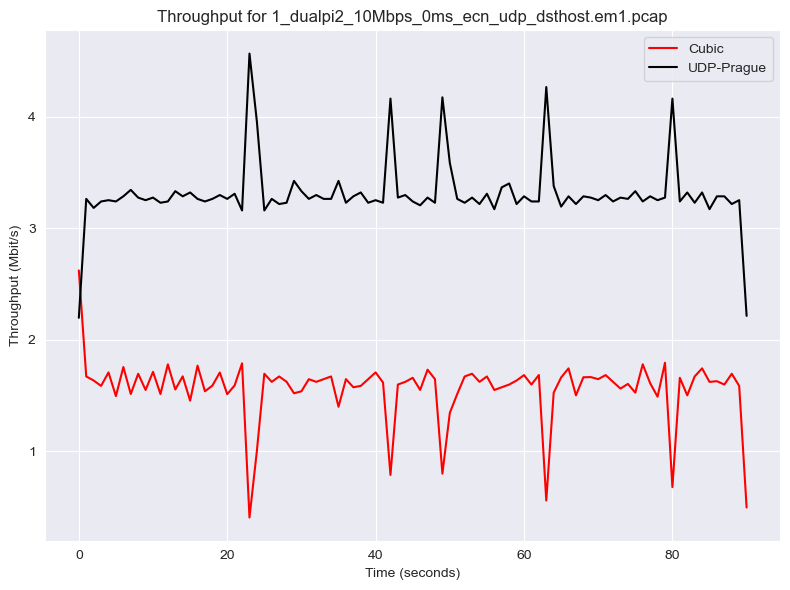

dict_items([(5101, 0), (5102, 18068041), (5103, 0), (8082, 37299960)])
Total throughput for 1_dualpi2_10Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 18068041, 5103: 0, 8082: 37299960}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


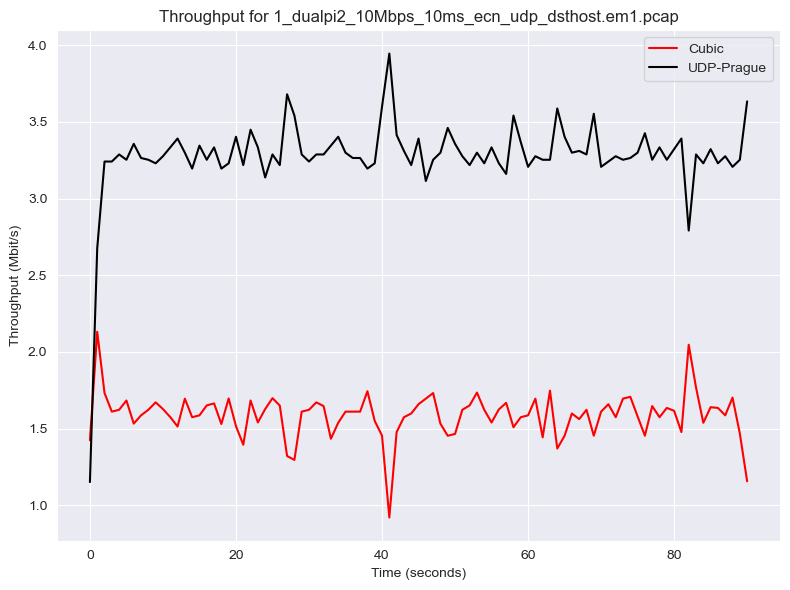

dict_items([(5101, 0), (5102, 18008047), (5103, 0), (8082, 37135770)])
Total throughput for 1_dualpi2_10Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 18008047, 5103: 0, 8082: 37135770}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


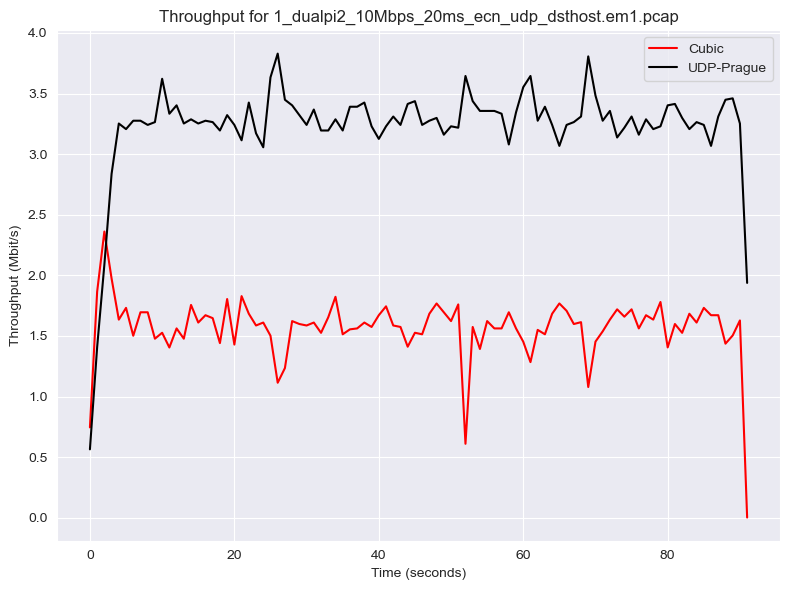

dict_items([(5101, 0), (5102, 18172779), (5103, 0), (8082, 37237741)])
Total throughput for 1_dualpi2_10Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 18172779, 5103: 0, 8082: 37237741}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


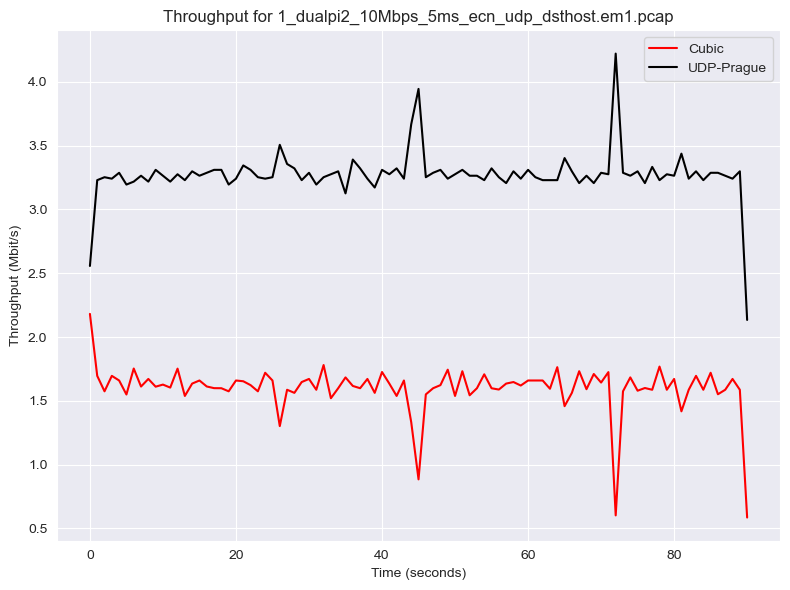

dict_items([(5101, 0), (5102, 584769450), (5103, 0), (8082, 220233584)])
Total throughput for 1_dualpi2_150Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 584769450, 5103: 0, 8082: 220233584}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


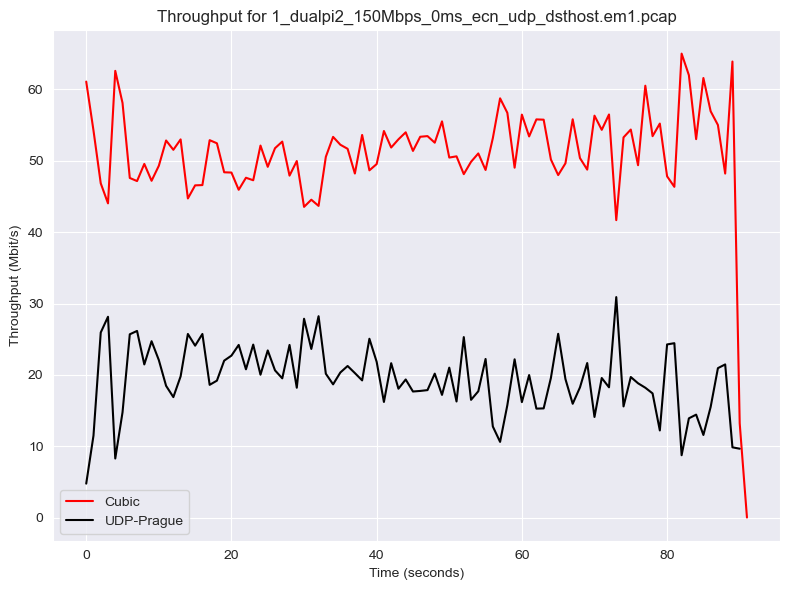

dict_items([(5101, 0), (5102, 574502855), (5103, 0), (8082, 190248574)])
Total throughput for 1_dualpi2_150Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 574502855, 5103: 0, 8082: 190248574}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


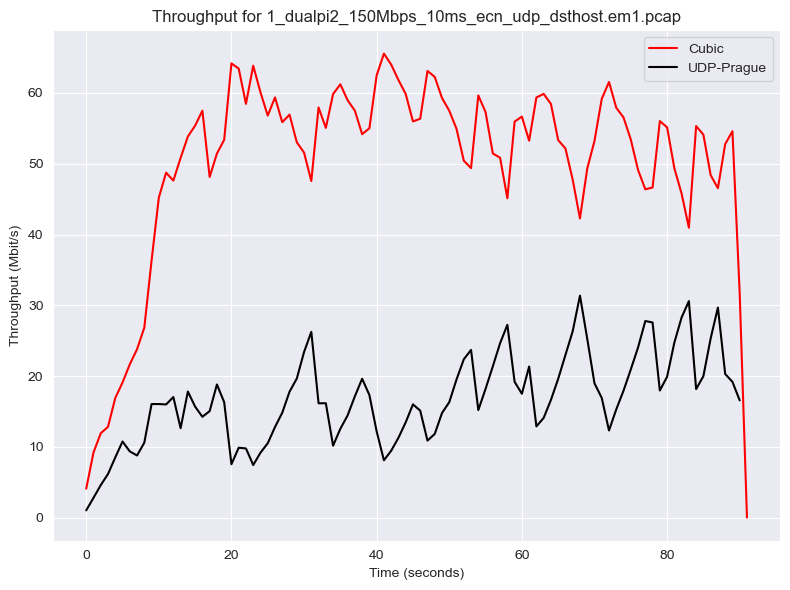

dict_items([(5101, 0), (5102, 470208978), (5103, 0), (8082, 111455404)])
Total throughput for 1_dualpi2_150Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 470208978, 5103: 0, 8082: 111455404}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


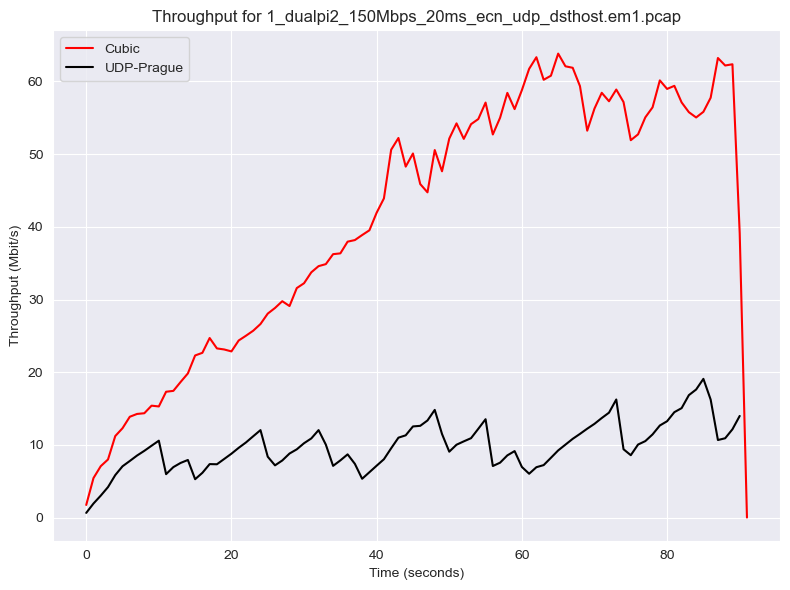

dict_items([(5101, 0), (5102, 562299787), (5103, 0), (8082, 246309466)])
Total throughput for 1_dualpi2_150Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 562299787, 5103: 0, 8082: 246309466}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


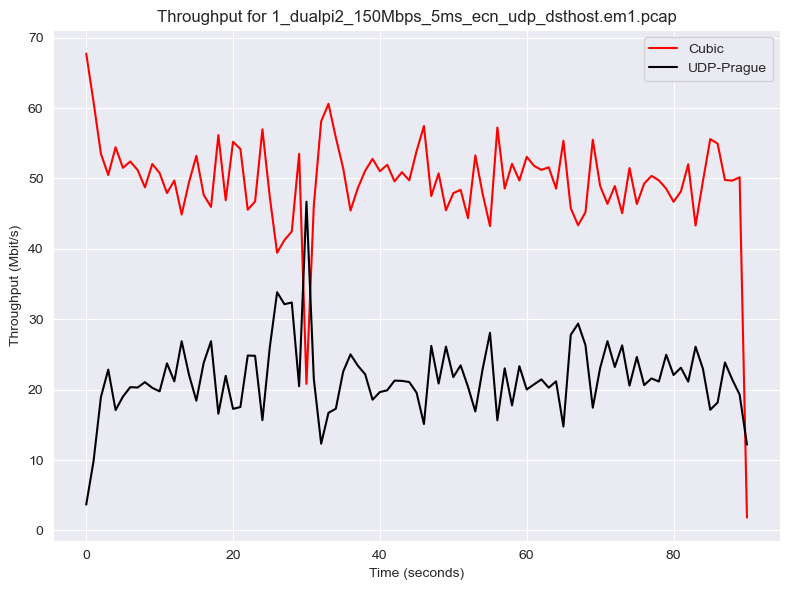

dict_items([(5101, 0), (5102, 33285252), (5103, 0), (8082, 77566430)])
Total throughput for 1_dualpi2_20Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 33285252, 5103: 0, 8082: 77566430}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


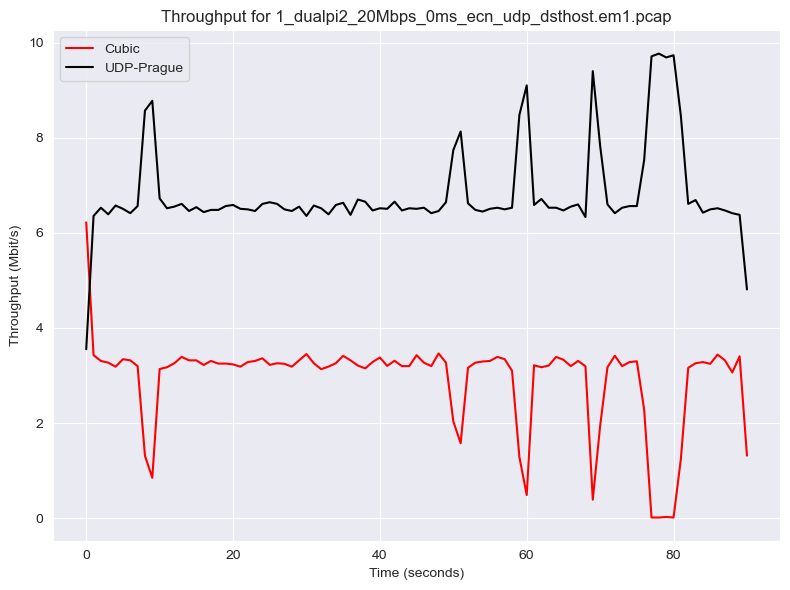

dict_items([(5101, 0), (5102, 37415364), (5103, 0), (8082, 73576750)])
Total throughput for 1_dualpi2_20Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 37415364, 5103: 0, 8082: 73576750}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


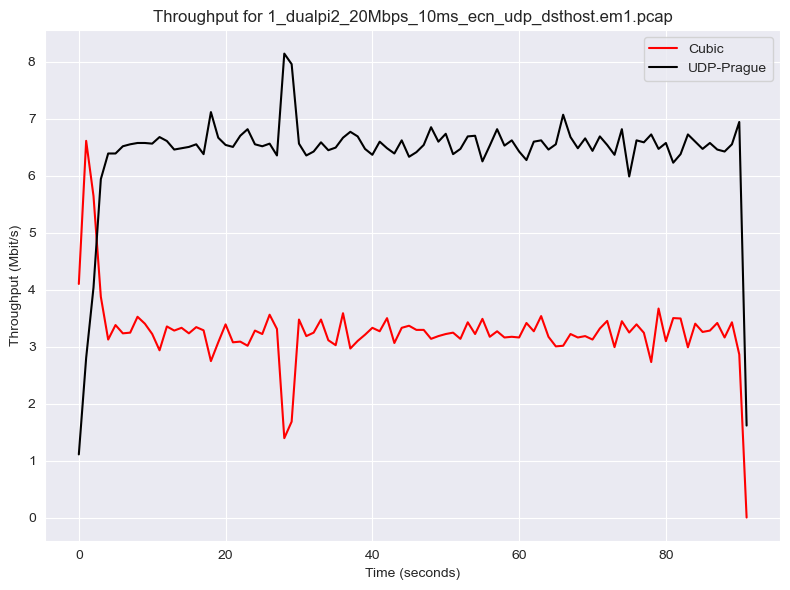

dict_items([(5101, 0), (5102, 36320395), (5103, 0), (8082, 73807470)])
Total throughput for 1_dualpi2_20Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 36320395, 5103: 0, 8082: 73807470}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


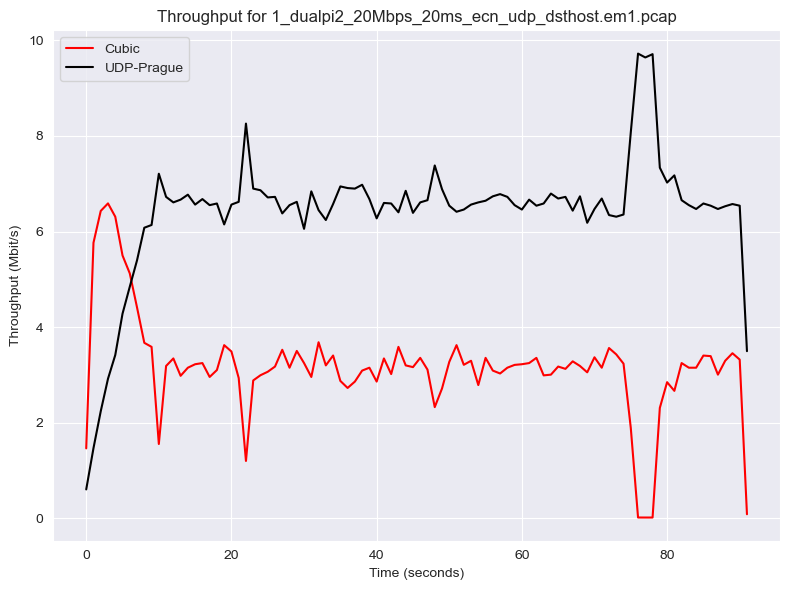

dict_items([(5101, 0), (5102, 32272727), (5103, 0), (8082, 79123986)])
Total throughput for 1_dualpi2_20Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 32272727, 5103: 0, 8082: 79123986}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


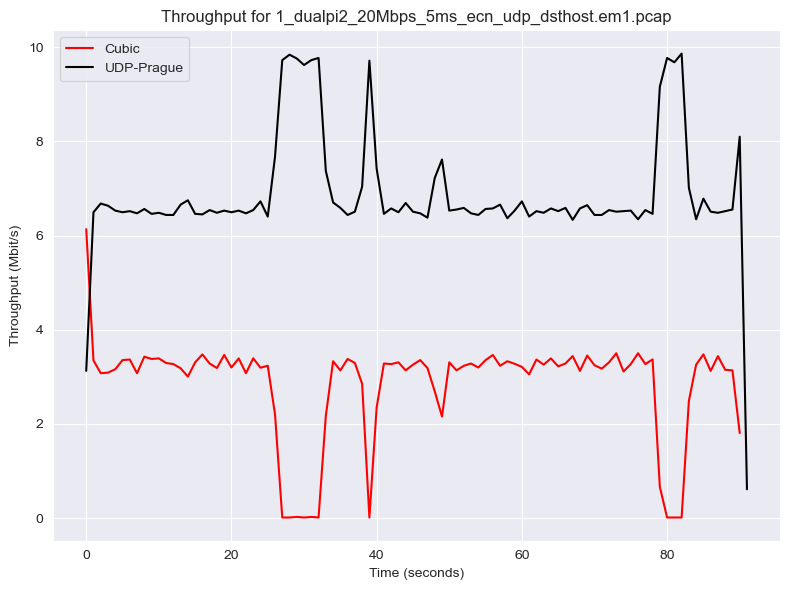

dict_items([(5101, 0), (5102, 8367900), (5103, 0), (8082, 19348215)])
Total throughput for 1_dualpi2_5Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 8367900, 5103: 0, 8082: 19348215}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


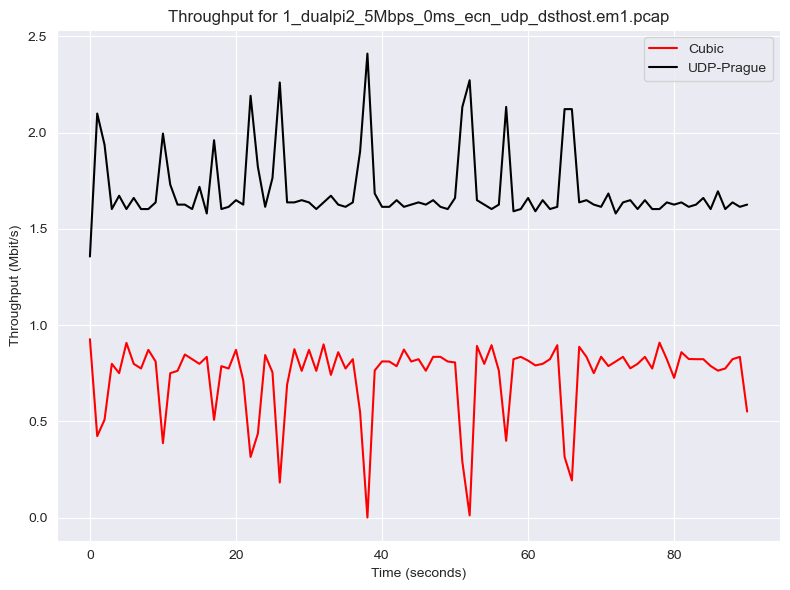

dict_items([(5101, 0), (5102, 8982126), (5103, 0), (8082, 18762004)])
Total throughput for 1_dualpi2_5Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 8982126, 5103: 0, 8082: 18762004}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


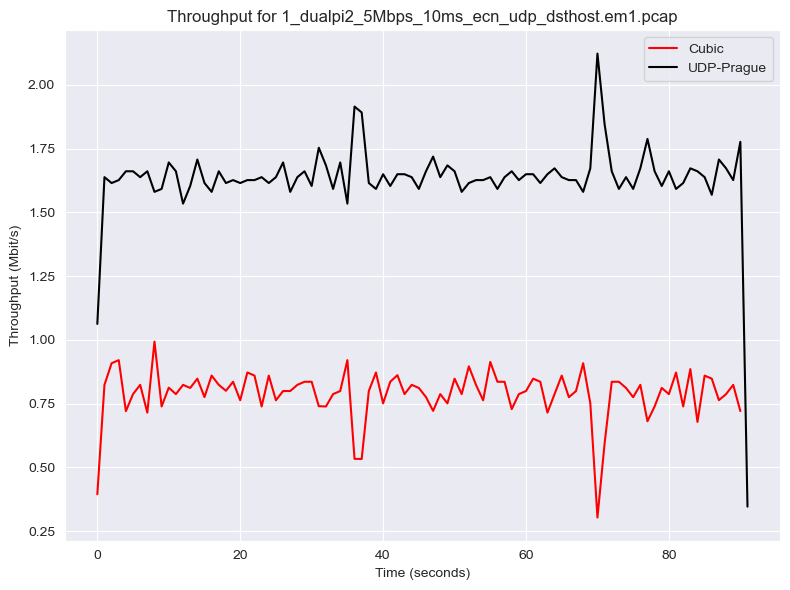

dict_items([(5101, 0), (5102, 8707730), (5103, 0), (8082, 18721628)])
Total throughput for 1_dualpi2_5Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 8707730, 5103: 0, 8082: 18721628}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


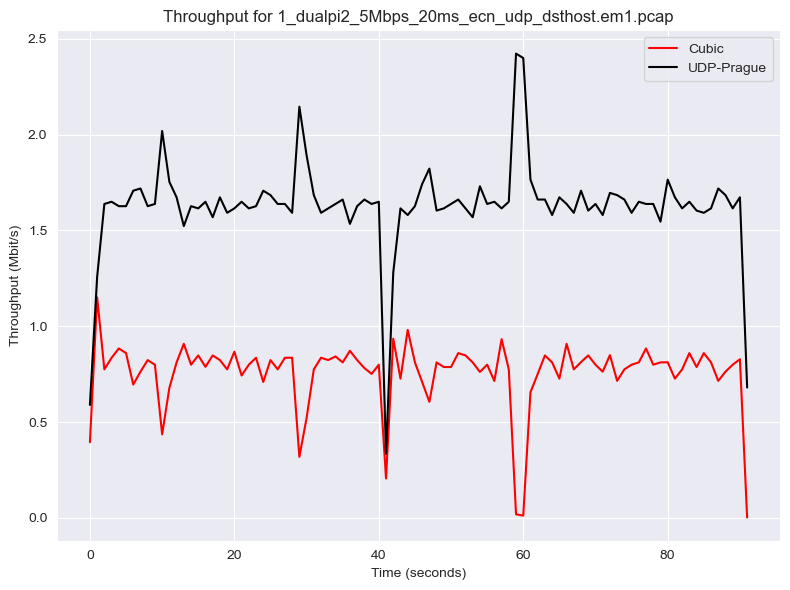

dict_items([(5101, 0), (5102, 8847963), (5103, 0), (8082, 18778627)])
Total throughput for 1_dualpi2_5Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 8847963, 5103: 0, 8082: 18778627}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


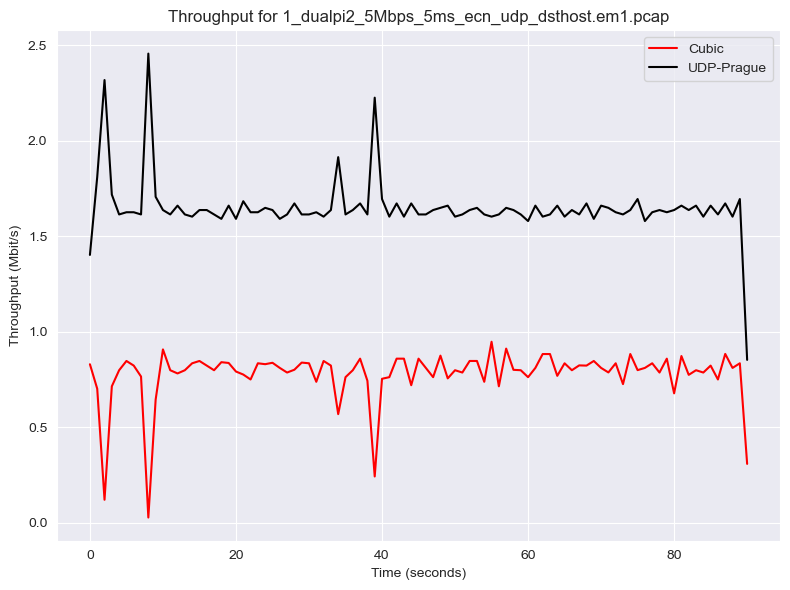

dict_items([(5101, 0), (5102, 278786115), (5103, 0), (8082, 265425711)])
Total throughput for 2_dualpi2_100Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 278786115, 5103: 0, 8082: 265425711}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


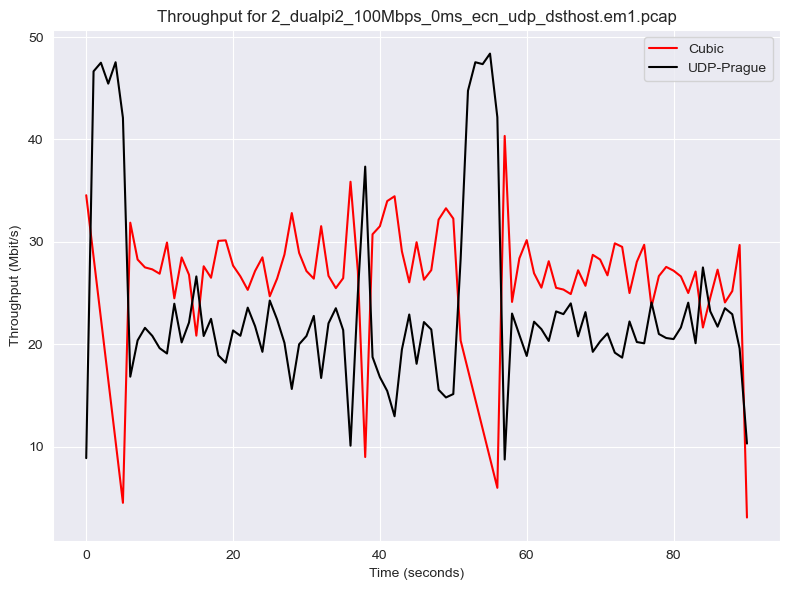

dict_items([(5101, 0), (5102, 297840071), (5103, 0), (8082, 232382768)])
Total throughput for 2_dualpi2_100Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 297840071, 5103: 0, 8082: 232382768}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


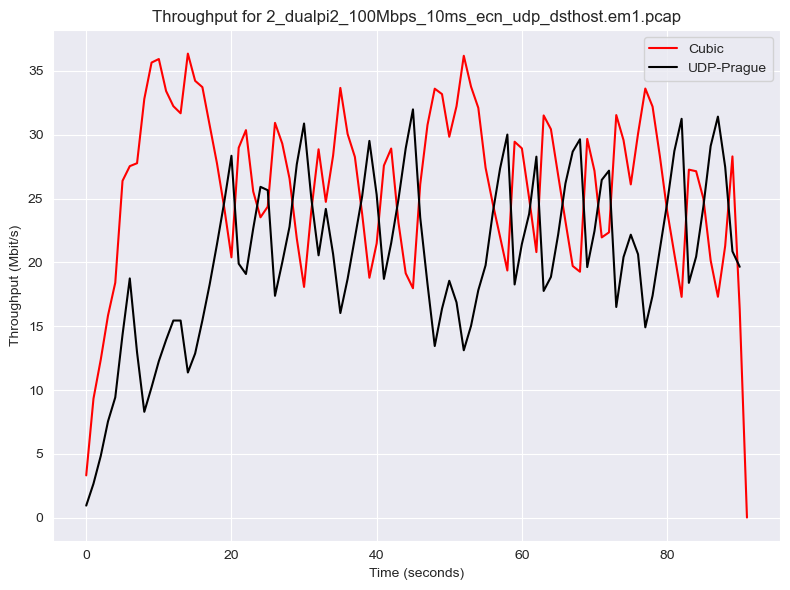

dict_items([(5101, 0), (5102, 322504537), (5103, 0), (8082, 139317728)])
Total throughput for 2_dualpi2_100Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 322504537, 5103: 0, 8082: 139317728}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


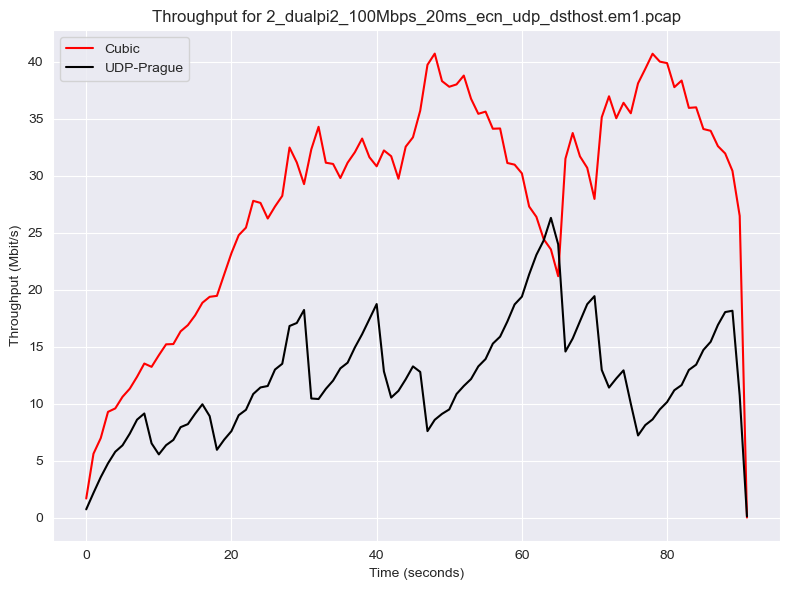

dict_items([(5101, 0), (5102, 313536660), (5103, 0), (8082, 234579888)])
Total throughput for 2_dualpi2_100Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 313536660, 5103: 0, 8082: 234579888}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


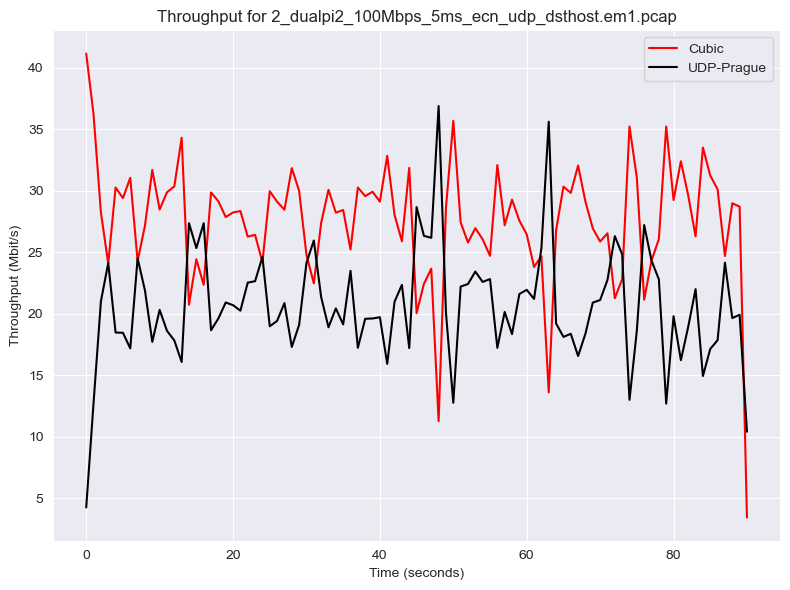

dict_items([(5101, 0), (5102, 15334351), (5103, 0), (8082, 40217384)])
Total throughput for 2_dualpi2_10Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 15334351, 5103: 0, 8082: 40217384}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


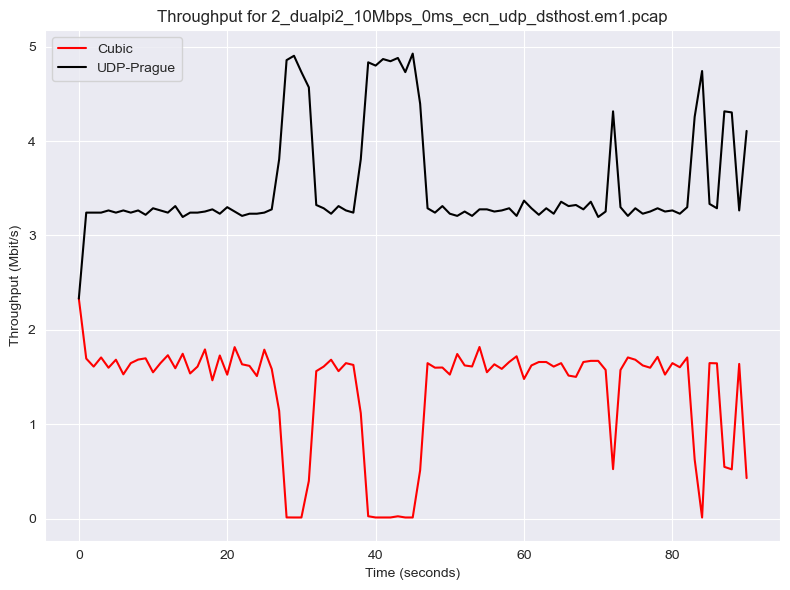

dict_items([(5101, 0), (5102, 18134848), (5103, 0), (8082, 37371014)])
Total throughput for 2_dualpi2_10Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 18134848, 5103: 0, 8082: 37371014}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


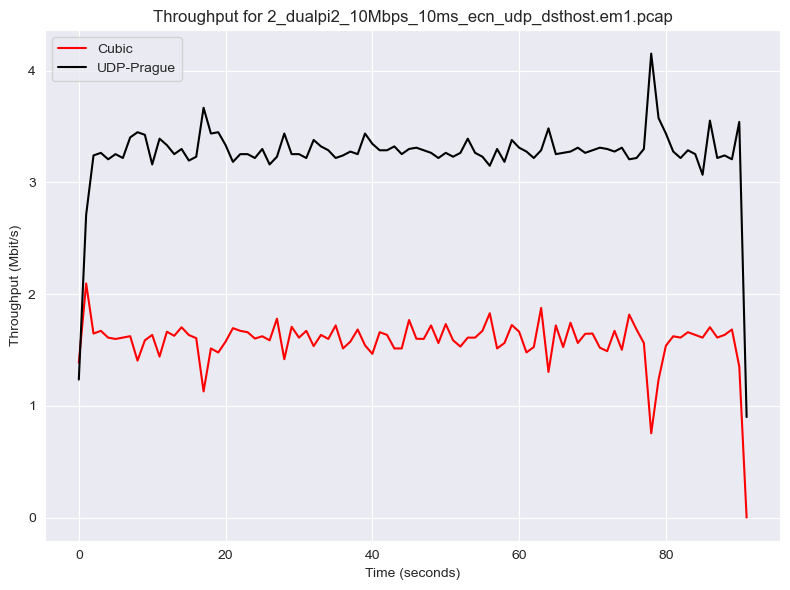

dict_items([(5101, 0), (5102, 18180796), (5103, 0), (8082, 36888340)])
Total throughput for 2_dualpi2_10Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 18180796, 5103: 0, 8082: 36888340}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


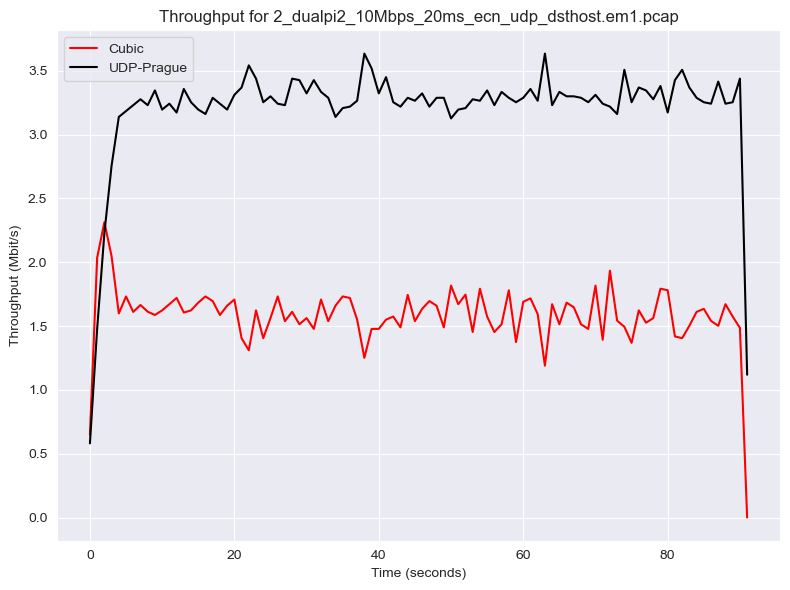

dict_items([(5101, 0), (5102, 18466135), (5103, 0), (8082, 36868886)])
Total throughput for 2_dualpi2_10Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 18466135, 5103: 0, 8082: 36868886}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


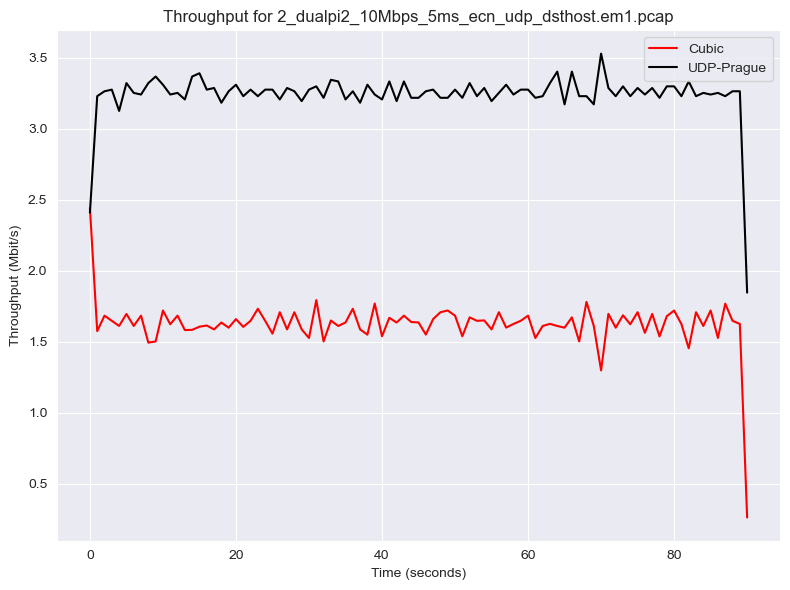

dict_items([(5101, 0), (5102, 574410509), (5103, 0), (8082, 237143570)])
Total throughput for 2_dualpi2_150Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 574410509, 5103: 0, 8082: 237143570}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


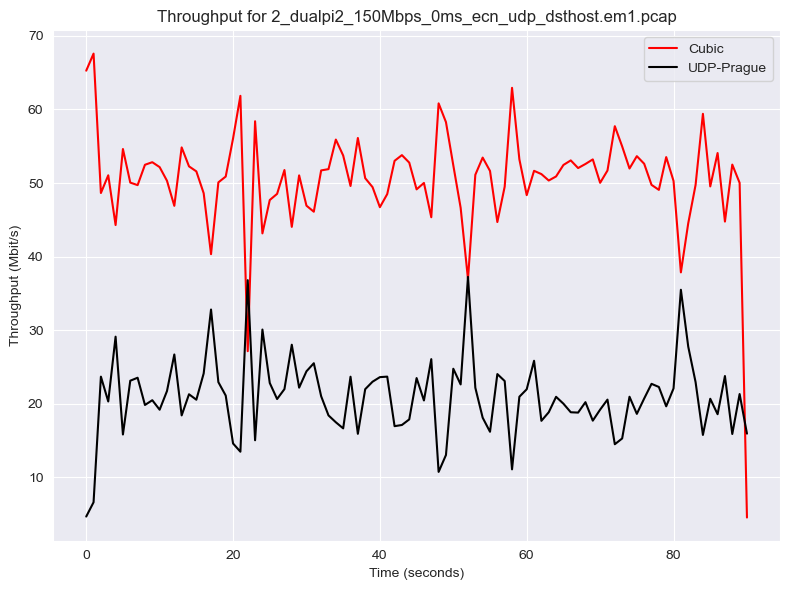

dict_items([(5101, 0), (5102, 557416714), (5103, 0), (8082, 195026316)])
Total throughput for 2_dualpi2_150Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 557416714, 5103: 0, 8082: 195026316}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


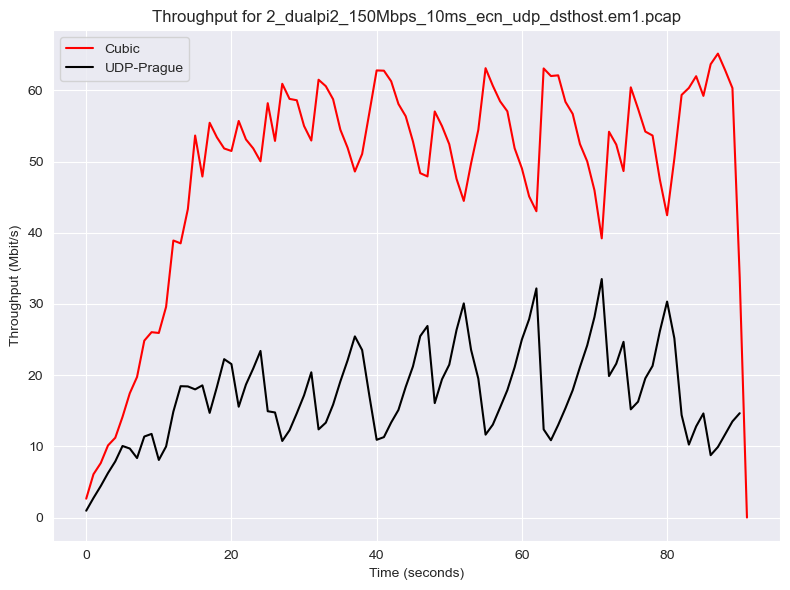

dict_items([(5101, 0), (5102, 469114194), (5103, 0), (8082, 99617828)])
Total throughput for 2_dualpi2_150Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 469114194, 5103: 0, 8082: 99617828}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


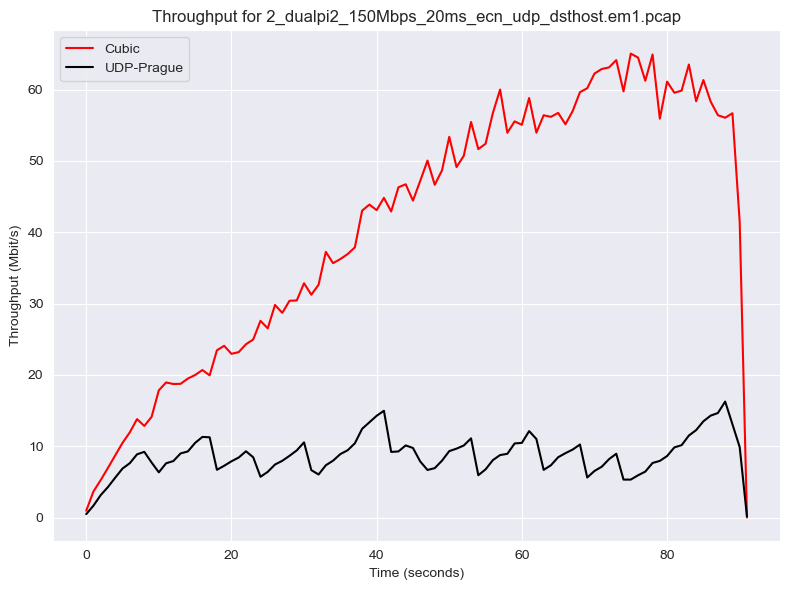

dict_items([(5101, 0), (5102, 275500228), (5103, 0), (8082, 506111722)])
Total throughput for 2_dualpi2_150Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 275500228, 5103: 0, 8082: 506111722}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


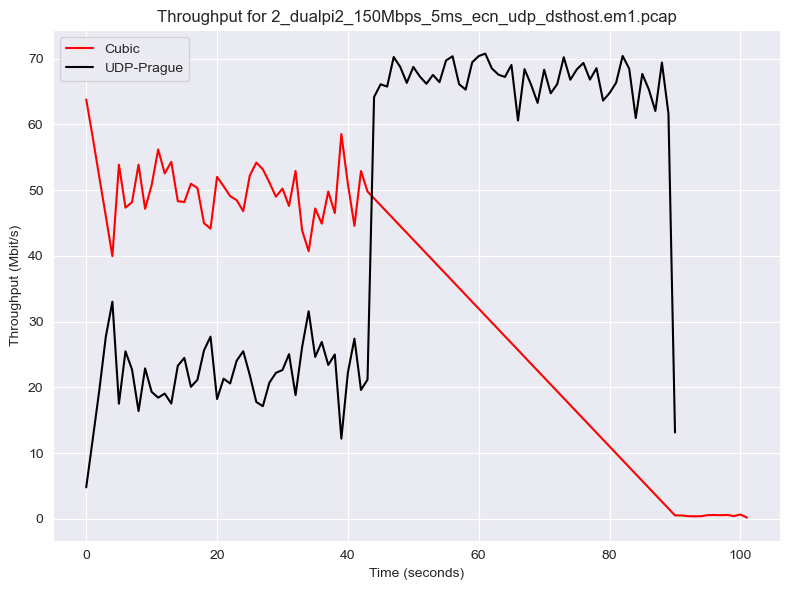

dict_items([(5101, 0), (5102, 25697019), (5103, 0), (8082, 85303503)])
Total throughput for 2_dualpi2_20Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 25697019, 5103: 0, 8082: 85303503}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


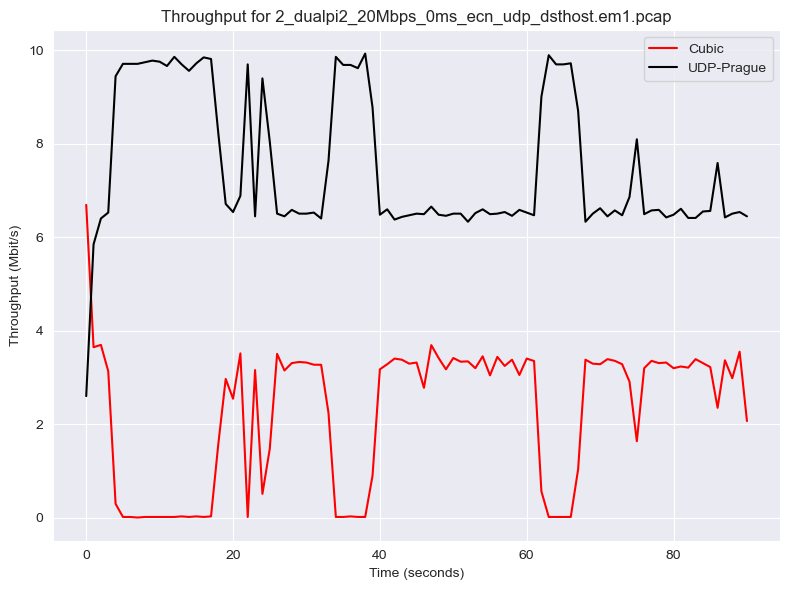

dict_items([(5101, 0), (5102, 37626992), (5103, 0), (8082, 73233356)])
Total throughput for 2_dualpi2_20Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 37626992, 5103: 0, 8082: 73233356}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


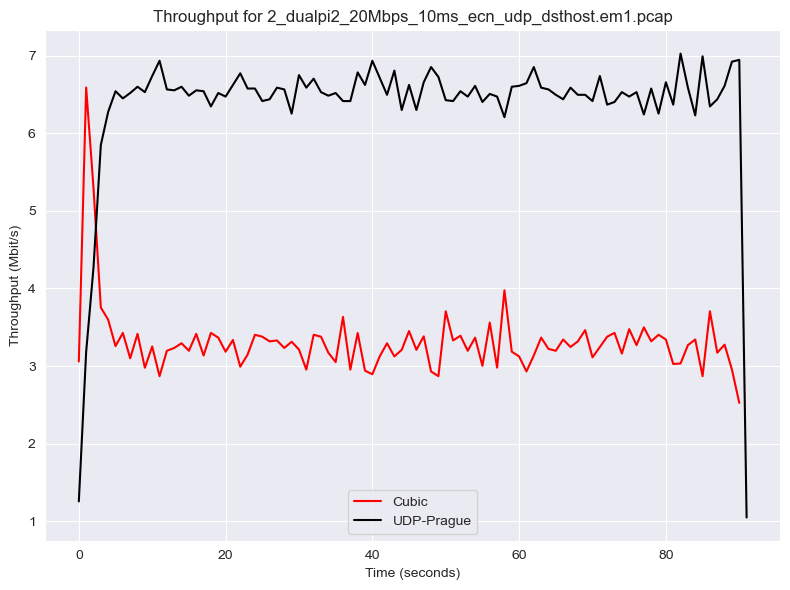

dict_items([(5101, 0), (5102, 37498666), (5103, 0), (8082, 71747050)])
Total throughput for 2_dualpi2_20Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 37498666, 5103: 0, 8082: 71747050}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


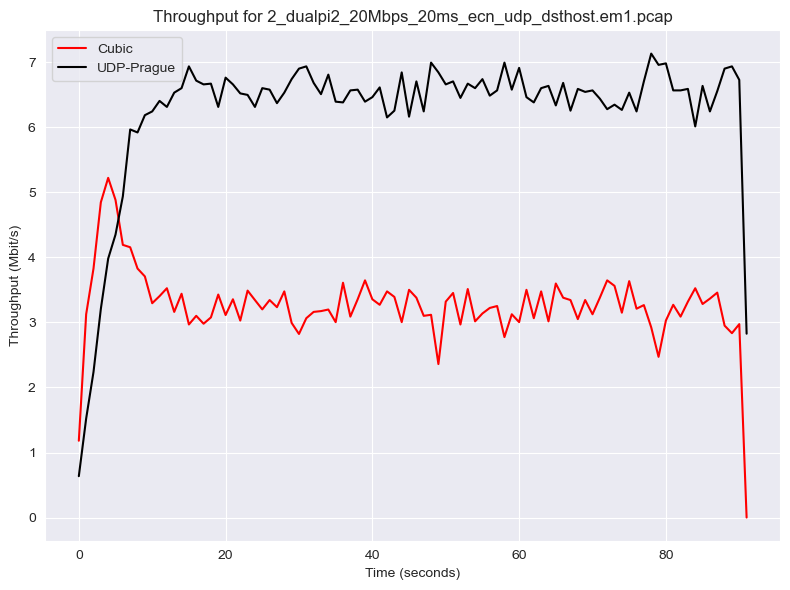

dict_items([(5101, 0), (5102, 30757164), (5103, 0), (8082, 79757571)])
Total throughput for 2_dualpi2_20Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 30757164, 5103: 0, 8082: 79757571}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


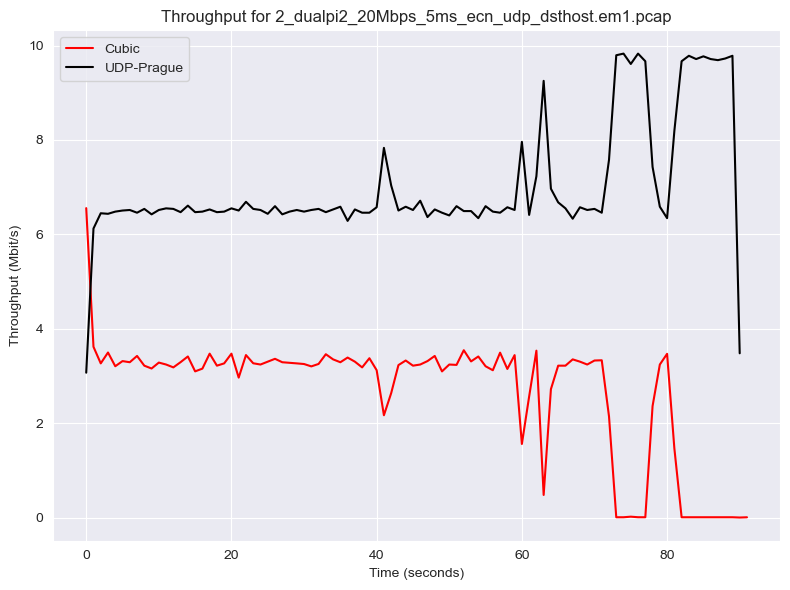

dict_items([(5101, 0), (5102, 8973820), (5103, 0), (8082, 18754307)])
Total throughput for 2_dualpi2_5Mbps_0ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 8973820, 5103: 0, 8082: 18754307}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


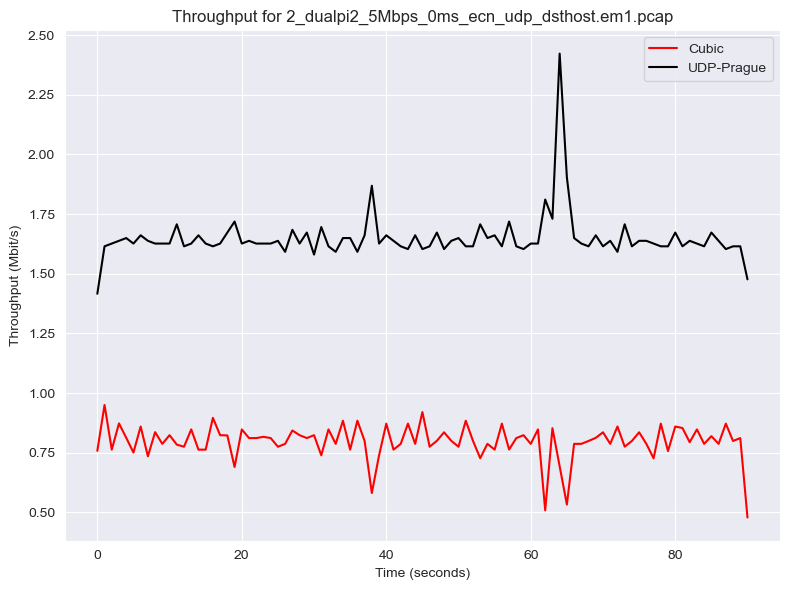

dict_items([(5101, 0), (5102, 8983551), (5103, 0), (8082, 18695672)])
Total throughput for 2_dualpi2_5Mbps_10ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 8983551, 5103: 0, 8082: 18695672}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


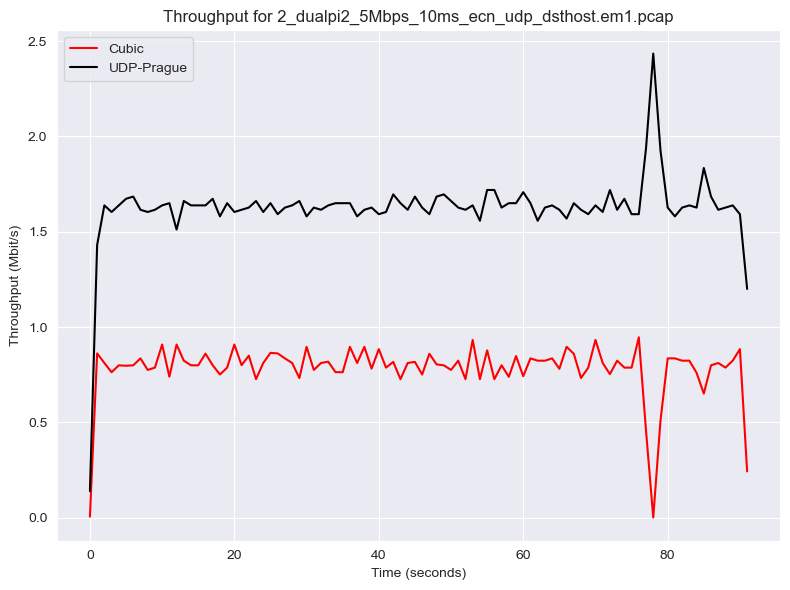

dict_items([(5101, 0), (5102, 8737197), (5103, 0), (8082, 18855734)])
Total throughput for 2_dualpi2_5Mbps_20ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 8737197, 5103: 0, 8082: 18855734}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


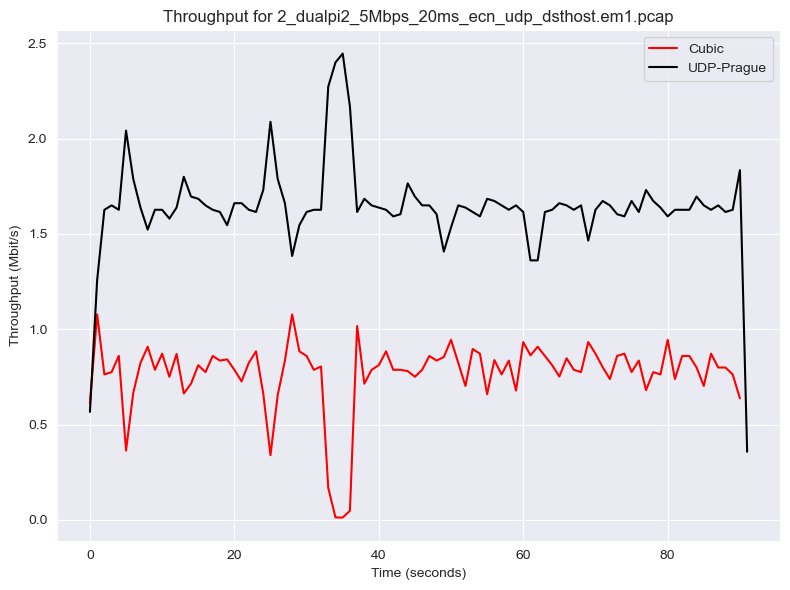

dict_items([(5101, 0), (5102, 7099747), (5103, 0), (8082, 20496374)])
Total throughput for 2_dualpi2_5Mbps_5ms_ecn_udp_dsthost.em1.pcap_throughput: {5101: 0, 5102: 7099747, 5103: 0, 8082: 20496374}
Directory already exists: ../data/udp_data_2025-04-27\Graphs


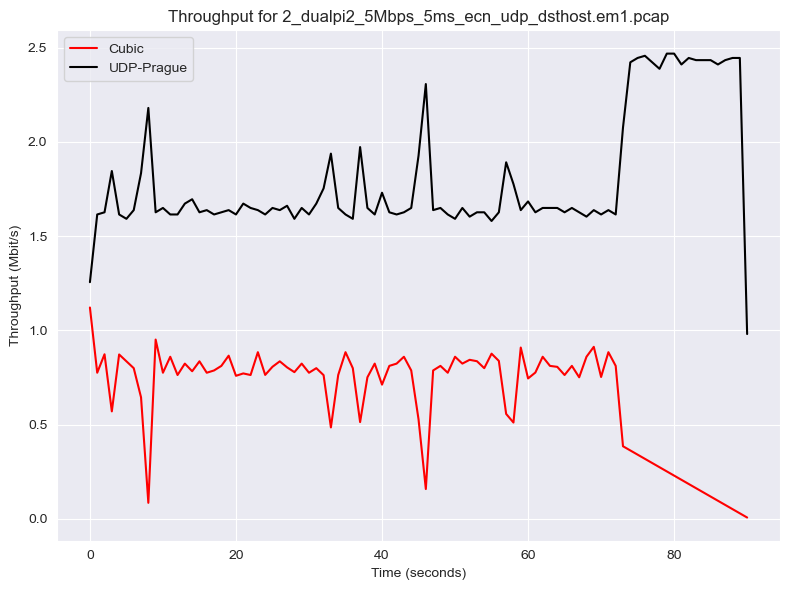

In [3]:
# Plot throughput for each pcap file
for filename, filepath in zip(filenames, filepaths):
    plot_throughput_with_siftr(
        file_path=filepath,
        ycolumn="Throughput (Mbit/s)",
        title=f"Throughput for {filename}",
        xlabel="Time (seconds)",
        ylabel="Throughput (Mbit/s)",
        filename=f"{filename}_throughput",
        graph_directory=graph_directory
    )